In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pyprojroot import here

import importlib.util

_spec = importlib.util.spec_from_file_location("opinion_functions", here() / "src" / "opinion_functions.py")
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
fun = _mod

In [3]:
SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

linewidth=0.5
dpival=200

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

colors=['#19bdff','#f2d138'] #majority/minority
greycolor='#626262'
lightgreycolor='#c4c4c4'
myblack='#222222'

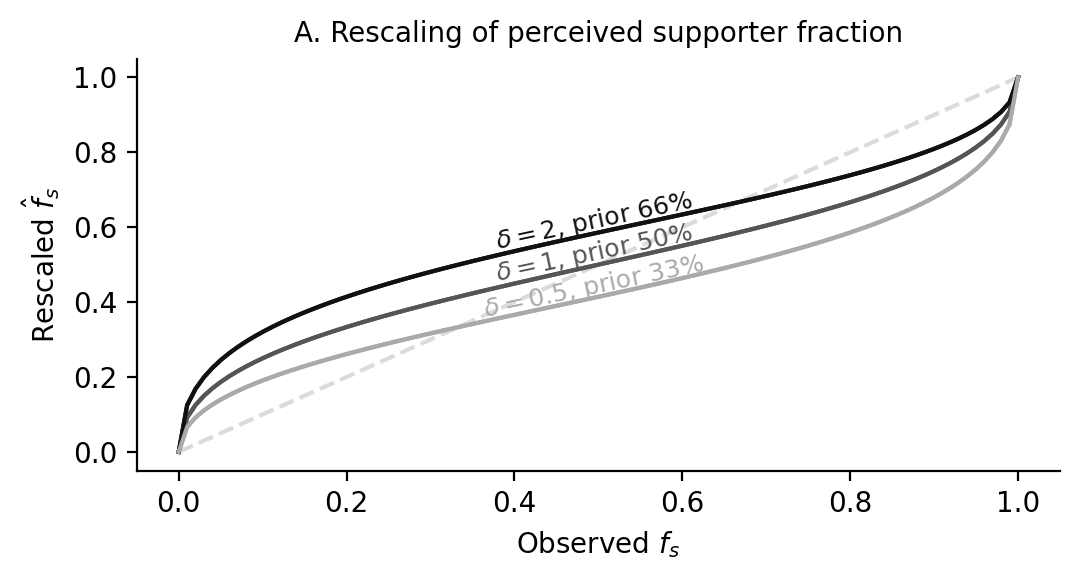

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Data
x = np.linspace(0, 1, 100)
y1 = fun.rescale_bayes(x, delta=1,   gamma=0.5)
y2 = fun.rescale_bayes(x, delta=2,   gamma=0.5)
y3 = fun.rescale_bayes(x, delta=0.5, gamma=0.5)

# Okabe–Ito colorblind-friendly palette

colors = {
    "low":  "#AAAAAA",   # delta=0.5  (light grey)
    "mid":  "#555555",   # delta=1    (medium grey)
    "high": "#111111",   # delta=2    (near-black)
    "grey": "#DCDBDB",   # identity line
}


plt.figure(dpi=dpival, figsize=(5.5, 3))

# Identity line (behind everything)
plt.plot(
    x, x,
    linestyle="--",
    color=colors["grey"],
    linewidth=1.5,
    zorder=0
)

# Curves
plt.plot(
    x, y1,
    color=colors["mid"],
    label=r"$\delta = 1$, prior 33%",
    zorder=2
)
plt.plot(
    x, y2,
    color=colors["high"],
    label=r"$\delta = 2$, prior 66%",
    zorder=2
)
plt.plot(
    x, y3,
    color=colors["low"],
    label=r"$\delta = 0.5$, prior 50%",
    zorder=2
)

# Choose an x-location near the middle
x_lab = 0.5
idx = np.argmin(np.abs(x - x_lab))

# Curves
plt.plot(x, y1, color=colors["mid"],  zorder=2)
plt.plot(x, y2, color=colors["high"], zorder=2)
plt.plot(x, y3, color=colors["low"],  zorder=2)

# Labels (slightly above the curves)
shift = -0.06

plt.text(
    x[idx], y2[idx] +shift ,
    r"$\delta = 2$, prior 66%",
    color=colors["high"],
    fontsize=9,
    ha="center",
    va="bottom",
    rotation=12
)
plt.text(
    x[idx], y1[idx] +shift,
    r"$\delta = 1$, prior 50%",
    color=colors["mid"],
    fontsize=9,
    ha="center",
    va="bottom",
    rotation=12
)
plt.text(
    x[idx], y3[idx] +shift -0.01,
    r"$\delta = 0.5$, prior 33%",
    color=colors["low"],
    fontsize=9,
    ha="center",
    va="bottom",
    rotation=12
)


plt.xlabel(r"Observed $f_s$")
plt.ylabel(r"Rescaled $\hat{f}_s$")
plt.title(r"A. Rescaling of perceived supporter fraction")

# plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(here("figures/rescale_bayes_variants.pdf"), dpi=dpival)
plt.show()